# Camera Autoencoder - tanitas

In [1]:
import os
import glob

import numpy as np
import torch
import matplotlib.pyplot as plt
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from torch.utils.data import DataLoader, TensorDataset, random_split
from PIL import Image

from ae import Autoencoder

torch.manual_seed(0)
np.random.seed(0)

print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

torch: 2.6.0+cu124 | cuda: True


---
## 1. Hiperparaméterek

In [2]:
DATA_DIR   = "dataset"        # ide gyujtott a collect_dataset.py
CACHE_NPY  = "images.npy"     # a betoltott kepek gyorsitotara

IMG_W, IMG_H = 160, 80        # a collect_dataset.py OBS_WIDTH/OBS_HEIGHT erteke

LATENT_DIM = 64               # a latent vektor hossza (ez megy majd az SAC-ba)
BASE_CH    = 32               # az elso conv reteg csatornaszama

BATCH_SIZE    = 128
LEARNING_RATE = 1e-3
MAX_EPOCHS    = 60
VAL_SPLIT     = 0.1           # a kepek 10%-a validaciora
NUM_WORKERS   = 4

---
## 2. Kepek betoltese `.npy` tombbe

In [3]:
def load_images(data_dir=DATA_DIR, cache=CACHE_NPY, force=False):
    """
    Beolvassa az osszes PNG-t egy (N, H, W, 3) uint8 tombbe.
    Ha letezik a cache fajl, azt tolti be helyette.
    """
    if os.path.exists(cache) and not force:
        arr = np.load(cache)
        print(f"cache-bol betoltve: {cache}  ->  {arr.shape}")
        return arr

    paths = sorted(glob.glob(os.path.join(data_dir, "*", "frames", "*.png")))

    print(f"{len(paths)} kep beolvasasa...")
    arr = np.zeros((len(paths), IMG_H, IMG_W, 3), dtype=np.uint8)

    for i, p in enumerate(paths):
        # convert("RGB"): a CARLA RGBA-t ment, az alfa csatorna nem kell
        img = Image.open(p).convert("RGB")
        if img.size != (IMG_W, IMG_H):
            img = img.resize((IMG_W, IMG_H), Image.BILINEAR)
        arr[i] = np.asarray(img)

        if (i + 1) % 1000 == 0:
            print(f"  {i + 1}/{len(paths)}")

    np.save(cache, arr)
    print(f"kesz -> {arr.shape}, elmentve: {cache}")
    return arr


images = load_images()

print()
print("alak :", images.shape, images.dtype)
print("meret:", images.nbytes / 1e6, "MB")
print("ertek:", images.min(), "-", images.max())

22759 kep beolvasasa...
  1000/22759
  2000/22759
  3000/22759
  4000/22759
  5000/22759
  6000/22759
  7000/22759
  8000/22759
  9000/22759
  10000/22759
  11000/22759
  12000/22759
  13000/22759
  14000/22759
  15000/22759
  16000/22759
  17000/22759
  18000/22759
  19000/22759
  20000/22759
  21000/22759
  22000/22759
kesz -> (22759, 80, 160, 3), elmentve: images.npy

alak : (22759, 80, 160, 3) uint8
meret: 873.9456 MB
ertek: 0 - 255


### pelda kepekre

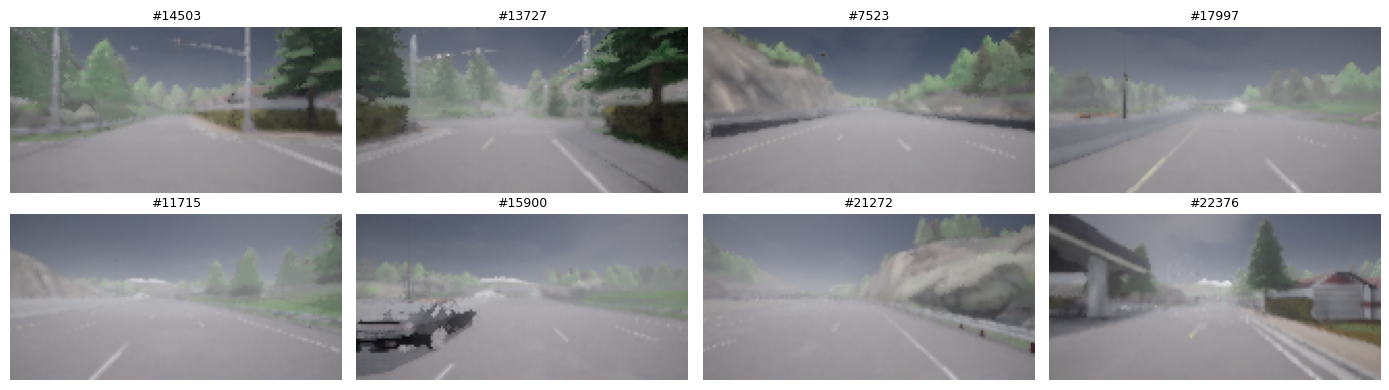

In [4]:
idx = np.random.choice(len(images), 8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 4))
for ax, i in zip(axes.flat, idx):
    ax.imshow(images[i])
    ax.set_title(f"#{i}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 3. Dataset es DataLoader

A numpy tombot atalakitjuk PyTorch tensorra:

- `(N, H, W, 3)` -> `(N, 3, H, W)` - a PyTorch conv retegei **csatorna-eloszor**
  varjak az adatot, a kepformatumok viszont csatorna-utoljara tarolnak.
- `uint8 [0,255]` -> `float32 [0,1]` - ezert oszunk 255-tel. Az `ae.py`
  vegen `Sigmoid` van, ami [0,1]-be szoritja a kimenetet, tehat a
  bemenetnek is ebben a tartomanyban kell lennie.

A teljes tombot egyben konvertaljuk float32-re. ~4000 kepnel ez kb. 630 MB
RAM - ez belefer. Ha sokkal tobb kepet gyujtesz, akkor erdemes lesz
uint8-ban tartani es a `collate_fn`-ben skalazni.

In [5]:
# (N, H, W, C) -> (N, C, H, W), majd [0,1]-re skalazas
x = torch.from_numpy(images).permute(0, 3, 1, 2).float().div_(255.0)
print("tensor:", x.shape, x.dtype, f"[{x.min():.2f}, {x.max():.2f}]")

# A TensorDataset (kep,) parokat ad vissza - egyelemu tuple-t.
# Az ae.py _shared_step-je `x, _ = batch` mintaval bont, ezert a
# cimke helyere odateszunk egy dummy nullas tensort.
dummy = torch.zeros(len(x))
dataset = TensorDataset(x, dummy)

n_val = int(len(dataset) * VAL_SPLIT)
n_train = len(dataset) - n_val
train_set, val_set = random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(0),
)
print(f"train: {n_train} | val: {n_val}")

train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0,
)
val_loader = DataLoader(
    val_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0,
)

tensor: torch.Size([22759, 3, 80, 160]) torch.float32 [0.00, 1.00]
train: 20484 | val: 2275


---
## 4. Modell


In [6]:
model = Autoencoder(latent_dim=LATENT_DIM, base_channels=BASE_CH, lr=LEARNING_RATE)

with torch.no_grad():
    probe = x[:2]
    z = model.encode(probe)
    recon = model(probe)

print("bemenet      :", tuple(probe.shape))
print("latent       :", tuple(z.shape))
print("rekonstrukcio:", tuple(recon.shape))
assert recon.shape == probe.shape, "a rekonstrukcio alakja nem egyezik a bemenettel!"

n_params = sum(p.numel() for p in model.parameters())
print(f"\nparameterek: {n_params / 1e6:.2f} M")

bemenet      : (2, 3, 80, 160)
latent       : (2, 64)
rekonstrukcio: (2, 3, 80, 160)

parameterek: 3.03 M


---
## 5. Tanitas

Ket callback:

- **`ModelCheckpoint`** - a legjobb validacios lossu sulyokat menti. Nem az
  utolso epoch a legjobb feltetlenul, ezert erdemes a legjobbat kulon eltenni.
- **`EarlyStopping`** - ha 10 epochon at nem javul a `val_loss`, leall.
  Igy nem kell talalgatni a `MAX_EPOCHS`-t.

In [7]:
ckpt = ModelCheckpoint(
    dirpath="checkpoints",
    filename="ae-{epoch:02d}-{val_loss:.5f}",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)
early = EarlyStopping(monitor="val_loss", mode="min", patience=10)

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices=1,
    callbacks=[ckpt, early],
    log_every_n_steps=10,
)

trainer.fit(model, train_loader, val_loader)

print("\nlegjobb checkpoint:", ckpt.best_model_path)
print("legjobb val_loss  :", float(ckpt.best_model_score))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
I0000 00:00:1788365588.429435   43463 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788365588.449693   43

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder   │ Sequential │  690 K │ train │     0 │
│ 1 │ fc_encode │ Linear     │  819 K │ train │     0 │
│ 2 │ fc_decode │ Linear     │  832 K │ train │     0 │
│ 3 │ decoder   │ Sequential │  690 K │ train │     0 │
└───┴───────────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.0 M                                                                                                
Total estimated model params size (MB): 12.128                                                                     
Modules in train mode: 27                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=60` reached.



legjobb checkpoint: /home/xavier11/CARLA/RL/RL-carla-ROS2/autoencoders/camera/checkpoints/ae-epoch=53-val_loss=0.00070.ckpt
legjobb val_loss  : 0.0007046337705105543


---
## 6. Mukodik az AE? - 4 random kep

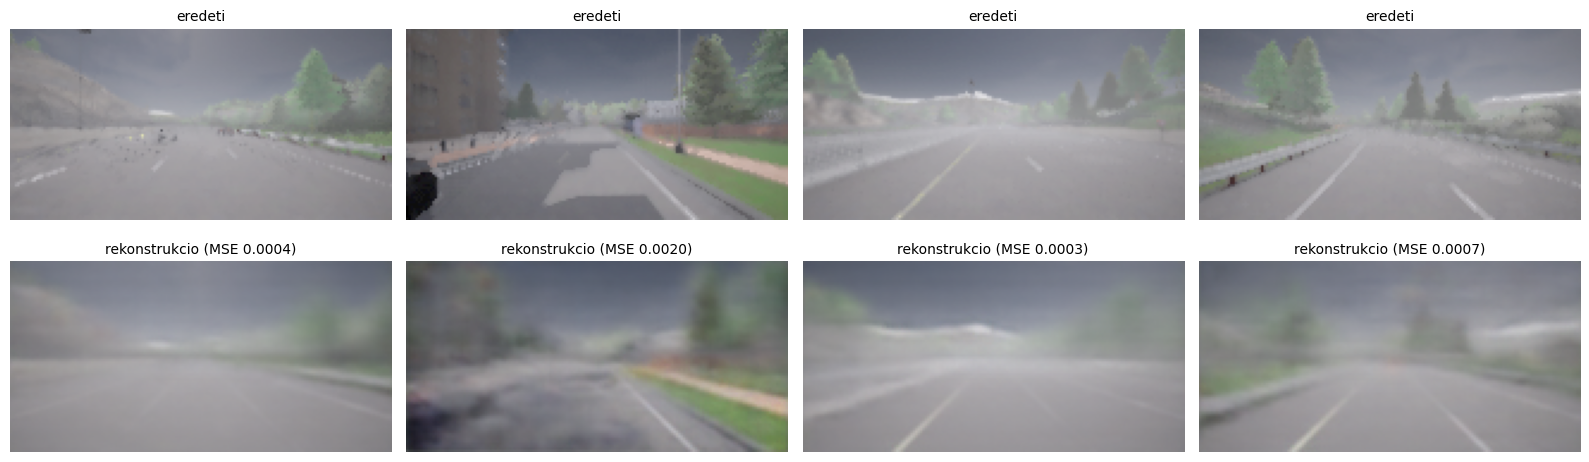

latent alakja : (4, 64)
atlagos MSE   : 0.0008625984191894531


In [8]:
# A legjobb sulyok visszatoltese (nem feltetlen az utolso epoch a legjobb)
best = Autoencoder.load_from_checkpoint(ckpt.best_model_path)
best.eval()
best.cpu()

# 4 random kep a VALIDACIOS halmazbol - olyan kepek, amiket a halo
# tanulas kozben soha nem latott. Ez a becsuletes teszt.
val_idx = np.random.choice(len(val_set), 4, replace=False)
originals = torch.stack([val_set[i][0] for i in val_idx])

with torch.no_grad():
    latents = best.encode(originals)
    recons = best(originals)

per_image_mse = ((recons - originals) ** 2).mean(dim=(1, 2, 3))

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for col in range(4):
    # felso sor: eredeti. (C,H,W) -> (H,W,C) a matplotlibnek
    axes[0, col].imshow(originals[col].permute(1, 2, 0).numpy())
    axes[0, col].set_title("eredeti", fontsize=10)
    axes[0, col].axis("off")

    # also sor: rekonstrukcio
    axes[1, col].imshow(recons[col].permute(1, 2, 0).numpy())
    axes[1, col].set_title(f"rekonstrukcio (MSE {per_image_mse[col]:.4f})", fontsize=10)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

print("latent alakja :", tuple(latents.shape))
print("atlagos MSE   :", float(per_image_mse.mean()))

In [ ]:
FINAL_PATH = "camera_ae.ckpt"

import shutil
shutil.copy(ckpt.best_model_path, FINAL_PATH)
print("elmentve:", FINAL_PATH)


elmentve: camera_ae.ckpt


: 